--- 1. ADIM: Dosya Aranıyor ve Yükleniyor ---
✅ Dosya bulundu: '../MarketSales.xlsx'
🎉 Veri başarıyla hafızaya alındı!

--- 2. ADIM: Veri Temizleniyor ve Hazırlanıyor ---
✅ Veri Hazır! Eğitim için 575551 satır kullanılacak.

--- 3. ADIM: AutoML Başlıyor (En iyi model aranıyor...) ---
⏳ Linear Regression modeli deneniyor...
   -> R2 Başarısı: 0.0335
⏳ Random Forest modeli deneniyor...
   -> R2 Başarısı: 0.0741
⏳ Gradient Boosting modeli deneniyor...
   -> R2 Başarısı: 0.0643

🏆 KAZANAN MODEL: Random Forest
🎯 En Yüksek R2 Skoru: 0.0741

--- 4. ADIM: Sonuçlar Görselleştiriliyor ---


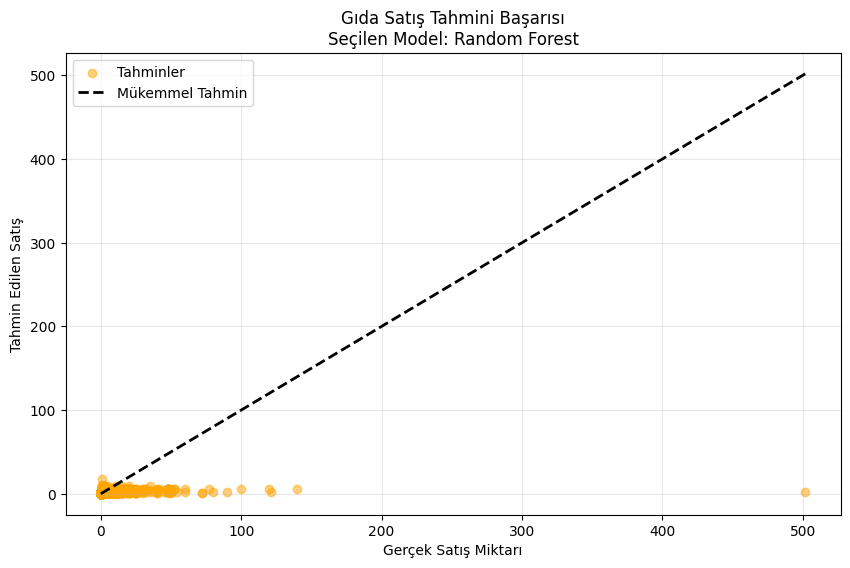

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# AutoML ve Regresyon Kütüphaneleri
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Uyarıları temizleyelim
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# 1. BÖLÜM: AKILLI DOSYA YÜKLEYİCİ (Dosyayı arayıp bulur)
# =============================================================================
print("--- 1. ADIM: Dosya Aranıyor ve Yükleniyor ---")

# Dosyanın olabileceği yerler listesi
olasi_yollar = [
    'MarketSales.xlsx', 'MarketSales.csv',              # Yanındaysa
    '../MarketSales.xlsx', '../MarketSales.csv',        # Bir üst klasördeyse
    'Python Kodları/MarketSales.xlsx',                  # Alt klasördeyse
    '/content/MarketSales.xlsx',                        # Colab kullanıyorsan
    'MarketSales'                                       # Uzantısız
]

df = None
bulunan_yol = ""

for yol in olasi_yollar:
    if os.path.exists(yol):
        print(f"✅ Dosya bulundu: '{yol}'")
        try:
            # Uzantısına veya içeriğine göre okumayı dene
            if yol.endswith('.csv'):
                df = pd.read_csv(yol)
            else:
                # Excel okurken hata verirse CSV gibi okumayı dene
                try:
                    df = pd.read_excel(yol)
                except:
                    df = pd.read_csv(yol)
            
            print("🎉 Veri başarıyla hafızaya alındı!")
            bulunan_yol = yol
            break
        except Exception as e:
            print(f"⚠️ Dosya var ama okunamadı ({yol}): {e}")

# Eğer dosya bulunamadıysa işlemi durdur
if df is None:
    print("\n🔴 KRİTİK HATA: 'MarketSales' dosyası bulunamadı!")
    print("Lütfen dosyanın adını veya yerini kontrol et.")
    # Burada kodu durdurmak için hata fırlatıyoruz
    raise FileNotFoundError("Dosya yüklenemediği için devam edilemiyor.")

# =============================================================================
# 2. BÖLÜM: VERİ HAZIRLIĞI (X ve y oluşturma)
# =============================================================================
print("\n--- 2. ADIM: Veri Temizleniyor ve Hazırlanıyor ---")

# Sütun isimlerindeki boşlukları temizle (Örn: " PRICE " -> "PRICE")
df.columns = df.columns.str.strip()

# Kullanacağımız sütunlar (Senin veri setine göre)
target_col = 'AMOUNT'
feature_cols = ['PRICE', 'CATEGORY_NAME1', 'BRAND']

# Sütunlar veri setinde var mı diye kontrol et
mevcut_cols = [c for c in feature_cols if c in df.columns]
if target_col not in df.columns:
    raise ValueError(f"Hata: Hedef sütun '{target_col}' veri setinde yok!")

# Alt veriyi oluştur ve boş satırları at
df_reg = df[[target_col] + mevcut_cols].dropna()

# Kategorik verileri sayıya çevir (One-Hot Encoding)
# Sadece string (object) olan sütunları seçip dönüştürür
cat_cols = df_reg.select_dtypes(include=['object']).columns.tolist()
if cat_cols:
    df_reg = pd.get_dummies(df_reg, columns=cat_cols, drop_first=True)

# X (Girdiler) ve y (Hedef) ayrımı
X = df_reg.drop([target_col], axis=1)
y = df_reg[target_col]

print(f"✅ Veri Hazır! Eğitim için {X.shape[0]} satır kullanılacak.")

# Eğitim ve Test seti ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =============================================================================
# 3. BÖLÜM: AUTOML (Farklı Modelleri Yarıştırma)
# =============================================================================
print("\n--- 3. ADIM: AutoML Başlıyor (En iyi model aranıyor...) ---")

# Yarıştırılacak Modeller
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor()
}

# Modellerin Deneyeceği Ayarlar (Parametreler)
params = {
    'Linear Regression': {},
    'Random Forest': {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]},
    'Gradient Boosting': {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1]}
}

best_model = None
best_r2 = -999

# Döngü ile hepsini dene
for name, model in models.items():
    print(f"⏳ {name} modeli deneniyor...")
    try:
        # RandomizedSearchCV: Rastgele parametre deneyerek en iyisini bulur
        clf = RandomizedSearchCV(model, params[name], n_iter=3, cv=3, scoring='r2', n_jobs=-1, random_state=42)
        clf.fit(X_train, y_train)
        
        # Test seti başarısını ölç
        score = clf.score(X_test, y_test)
        print(f"   -> R2 Başarısı: {score:.4f}")
        
        # En iyisi mi diye kontrol et
        if score > best_r2:
            best_r2 = score
            best_model = clf.best_estimator_
            best_model_name = name
            
    except Exception as e:
        print(f"   -> Hata oluştu: {e}")

print(f"\n🏆 KAZANAN MODEL: {best_model_name}")
print(f"🎯 En Yüksek R2 Skoru: {best_r2:.4f}")

# =============================================================================
# 4. BÖLÜM: GRAFİK ÇİZDİRME
# =============================================================================
print("\n--- 4. ADIM: Sonuçlar Görselleştiriliyor ---")

final_predictions = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
# Gerçek vs Tahmin saçılım grafiği
plt.scatter(y_test, final_predictions, alpha=0.5, color='orange', label='Tahminler')
# Mükemmel tahmin çizgisi (y=x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Mükemmel Tahmin')

plt.xlabel('Gerçek Satış Miktarı')
plt.ylabel('Tahmin Edilen Satış')
plt.title(f'Gıda Satış Tahmini Başarısı\nSeçilen Model: {best_model_name}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()